In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import seaborn as sns

from pyfish import process_data, setup_figure, fish_plot
from matplotlib.sankey import Sankey

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams, colors, cm
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 100)

In [78]:
df = pd.read_excel("../../data/data_cleaned.xlsx")

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [79]:
df["GPSC"] = df["GPSC"].astype("string")
df["serotype_cons"] = df["serotype_cons"].astype("string")
df["serotype_geno"] = df["serotype_geno"].astype("string")
df["serotype_pheno"] = df["serotype_pheno"].astype("string")
df["ST"] = df["ST"].astype("string")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df["age"] = df["age"].round().astype("Int64")

In [80]:
# vaccines introduction
pcv7 = 2006
pcv13 = 2011
covid19 = 2020
pcv15 = 2023

In [81]:
def generate_shades(base_color, n):
    """Generate n distinct shades of the base color by varying lightness."""
    import colorsys
    base_rgb = mcolors.to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*base_rgb)
    lightness_values = np.linspace(max(0.3, l - 0.3), min(0.8, l + 0.3), n)
    shades = [colorsys.hls_to_rgb(h, lv, s) for lv in lightness_values]
    return [mcolors.to_hex(rgb) for rgb in shades]

# Define serotype groups by PCV category
pcv7 = ["4", "6B", "9V", "14", "18C", "19F", "23F"]
pcv13 = ["1", "3", "5", "6A", "7F", "19A"]
pcv15 = ["22F", "33F"]
pcv20 = ["8", "10A", "11A", "12F", "15B"]
ppv23 = ["2", "9N", "17F", "20"]
v116 = ["15A", "15C", "16F", "23A", "23B", "24F", "31", "35B"]

# Base colors per PCV group
base_colors = {
    "pcv7": "#ff474c",    # light red
    "pcv13": "#b790d4",   # pale purple
    "pcv15": "#a9f971",   # spring green
    "pcv20": "#0652ff",   # blue
    "ppv23": "#a0d2f2",   # very pale blue
    "v116": "#ae7181"  # mauve
}

# Generate shades for each group
shades_pcv7 = generate_shades(base_colors["pcv7"], len(pcv7))
shades_pcv13 = generate_shades(base_colors["pcv13"], len(pcv13))
shades_pcv15 = generate_shades(base_colors["pcv15"], len(pcv15))
shades_pcv20 = generate_shades(base_colors["pcv20"], len(pcv20))
shades_ppv23 = generate_shades(base_colors["ppv23"], len(ppv23))
shades_v116 = generate_shades(base_colors["v116"], len(v116))

# Combine into dictionary 'soi'
soi = {}

for st, color in zip(pcv7, shades_pcv7):
    soi[st] = color
for st, color in zip(pcv13, shades_pcv13):
    soi[st] = color
for st, color in zip(pcv15, shades_pcv15):
    soi[st] = color
for st, color in zip(pcv20, shades_pcv20):
    soi[st] = color
for st, color in zip(ppv23, shades_ppv23):
    soi[st] = color
for st, color in zip(v116, shades_v116):
    soi[st] = color

soi["38"] = "#f97306"

In [82]:
df

,lab-nr,working-nr,sample-nr,patient-nr,material,others,sepsis,HIV+,meningitis,covid,date,age,sex,serotype_pheno,serotype_geno,serogroup_match,serotype_match,serotype_cons,serotype_cons_reason,ST,GPSC,bad_quality,penicillin_men_geno,penicillin_nonmen_geno,penicillin_MIC_geno,pbp1a,pbp2b,pbp2x,ceftriaxone_men_geno,ceftriaxone_nonmen_geno,ceftriaxone_MIC_geno,amoxicillin_geno,amoxicillin_MIC_geno,year,vaccine_period,isVT,isPCV7,isPCV13,isPCV15,age_group,isNVT,pre-PCV7,PCV7,early-PCV13,late-PCV13,PCV15,COVID19,dominant_serotype,dominant_GPSC
0,3727299,1,1212.09,1387686.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-30,88,M,17F,17F,Match,Match,17F,NaN,1924,49,NaN,S,S,0.03,11,0,172,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,0,0.0
1,3727298,2,1212.08,991560.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-29,71,M,3,3,Match,Match,3,NaN,1377,83,NaN,S,S,0.03,62,0,2,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,>=65 years,0,0,0,0,0,0,1,1,1.0
2,3726089,3,1211.77,500374.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-28,66,F,8,8,Match,Match,8,NaN,53,3,NaN,S,S,0.03,3,6,5,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0
3,3725476,4,1211.70,1652756.0,material_blood,1.0,0.0,0.0,1.0,1.0,2022-03-26,55,F,19A,19A,Match,Match,19A,NaN,199,4,NaN,S,S,0.03,1,0,187,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,45-64 years,0,0,0,0,0,0,1,1,1.0
4,3718136,5,1211.49,555401.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-20,65,M,12F,12F,Match,Match,12F,NaN,218,32,NaN,S,S,0.03,0,0,0,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,24K-351B0173,1342,1248.14,NaN,material_other,NaN,NaN,NaN,NaN,NaN,2024-12-14,63,M,22F,22F,Match,Match,22F,NaN,433,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,45-64 years,0,0,0,0,0,1,0,1,1.0
1308,24K-351B0174,1343,1248.15,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,78,M,19F,19F,Match,Match,19F,NaN,179,44,> 150 contigs,S,S,0.03,23,0,139,S,S,0.5,S,0.03,2024,PCV15,1,1,0,0,>=65 years,0,0,0,0,0,1,0,1,0.0
1309,24K-351B0255,1344,1248.17,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,58,M,35B,35B,Match,Match,35B,NaN,3003,72,NaN,S,S,0.03,0,0,2,S,S,0.5,S,0.03,2024,PCV15,0,0,0,0,45-64 years,1,0,0,0,0,1,0,0,0.0
1310,24K-360B0073,1345,1248.63,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-24,84,F,22F,22F,Match,Match,22F,NaN,10220,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,>=65 years,0,0,0,0,0,1,0,1,1.0


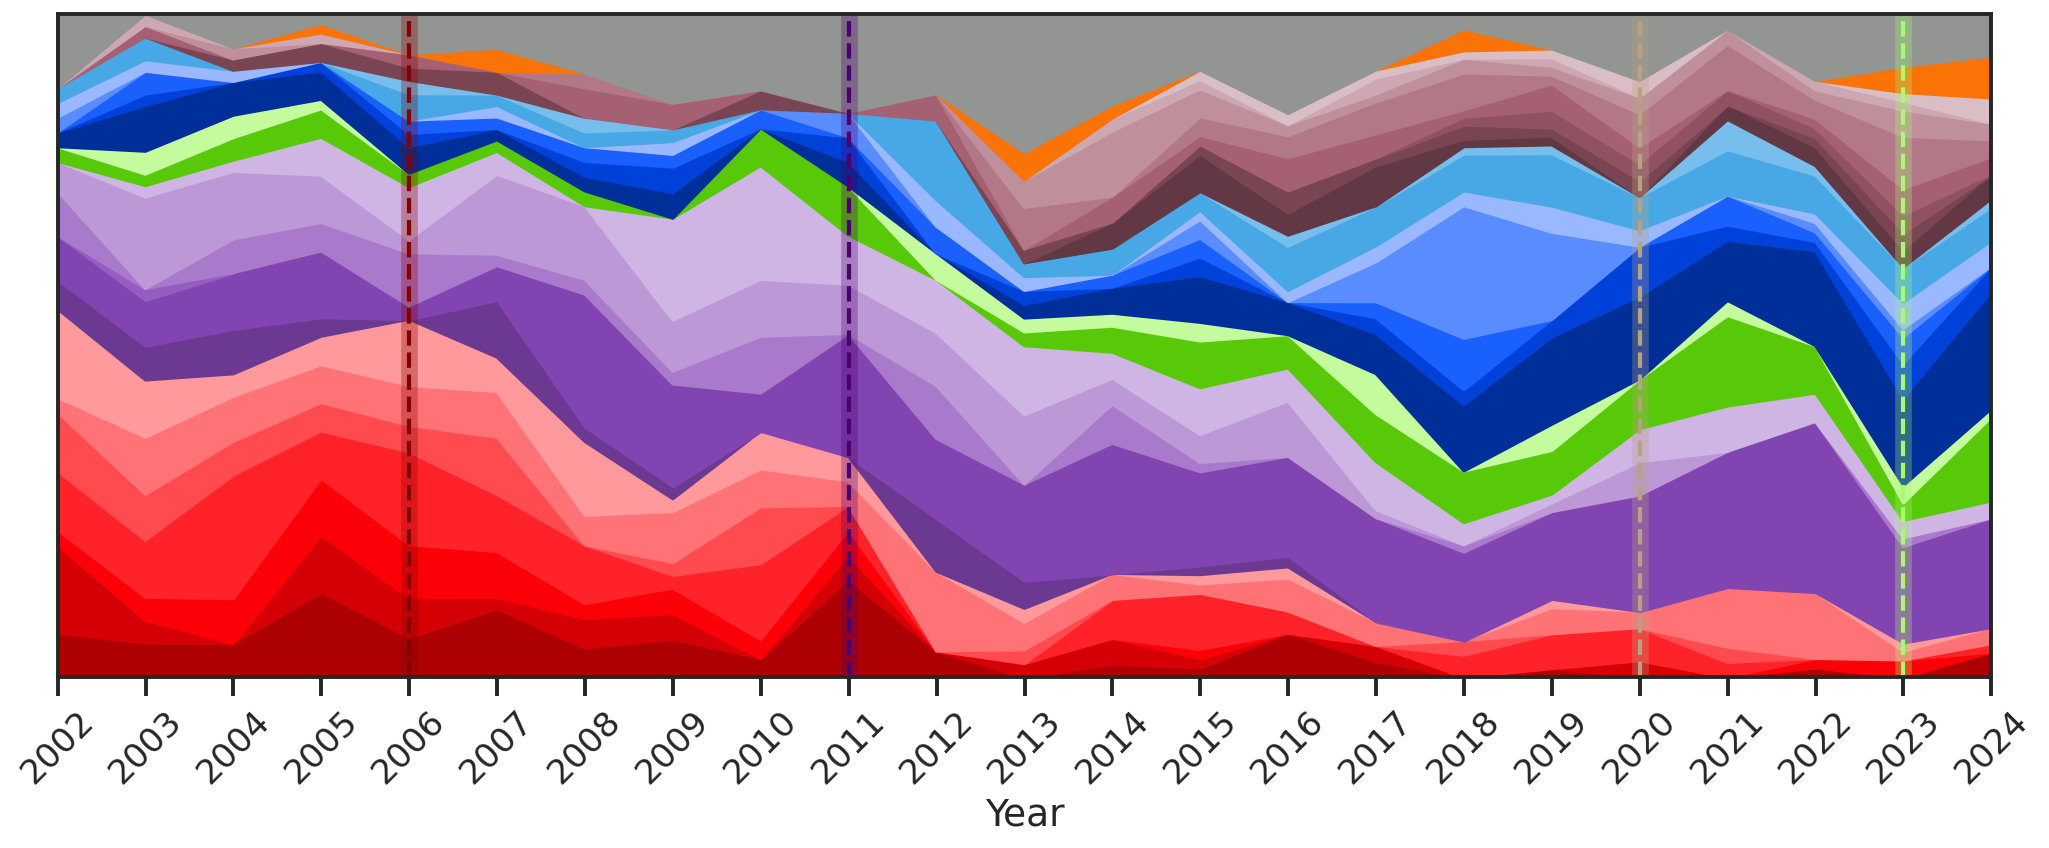

In [83]:
# get dominant serotypes
dominant_serotypes = (
    df.loc[df["dominant_serotype"] == 1, "serotype_cons"]
    .dropna()
    .unique()
    .tolist()
)

# serotypes to add on top of soi:
# these are dominant but NOT already in soi
additional_serotypes = [st for st in dominant_serotypes if st not in soi]

# serotype list to plot
all_serotypes = set(soi.keys()) | set(additional_serotypes) | {"Others"}

# map each serotype to an ID (for fishplot)
id_map = {st: i+1 for i, st in enumerate(sorted(all_serotypes))}

# filter dataset serotypes: only those in all_serotypes, else 'Others'
df['serotype_filtered_plot'] = df['serotype_cons'].where(df['serotype_cons'].isin(all_serotypes), 'Others')

# aggregate counts by filtered serotype and year
counts = (
    df.groupby(['serotype_filtered_plot', 'year'])
    .size()
    .reset_index(name='count')
)

# prepare year steps for fishplot
unique_years = sorted(counts['year'].unique())
step_map = {year: i for i, year in enumerate(unique_years)}

# build fishplot DataFrame
fish_data = []
for _, row in counts.iterrows():
    fish_data.append([
        id_map[row['serotype_filtered_plot']],
        step_map[row['year']],
        row['count'],
        'VOC',
        row['serotype_filtered_plot']
    ])
fish_df = pd.DataFrame(fish_data, columns=['Id', 'Step', 'Pop', 'VOC', 'clade'])

# parent tree (optional)
parent_tree_df = pd.DataFrame({'ParentId': 0, 'ChildId': fish_df['Id'].unique()})

# --- Color assignment ---
# Define ordered list of clades: soi in order, then additional STs, then Others
ordered_clades = list(soi.keys()) + additional_serotypes + ['Others']

# Reds palette for additional top serotypes
pal_reds = sns.color_palette('Reds', max(len(additional_serotypes), 3))

color_dict = {}

# Assign colors from soi dictionary
for st, hex_color in soi.items():
    color_dict[st] = colors.to_rgba(hex_color)

# Assign red tones to additional serotypes (if not already in soi)
for i, st in enumerate(additional_serotypes):
    if st not in color_dict:
        color_dict[st] = (*pal_reds[i % len(pal_reds)], 1.0)

# Assign grey to 'Others'
color_dict['Others'] = colors.to_rgba('xkcd:grey')

# Ensure ALL ordered_clades have a color (including any missed)
for st in ordered_clades:
    if st not in color_dict:
        color_dict[st] = colors.to_rgba('xkcd:grey')

# --- Prepare data for fish_plot ---

# Create pivot table and reindex only with clades that exist in the data
pivotted = (
    fish_df.pivot_table(index='clade', columns='Step', values='Pop', aggfunc='sum')
    .fillna(0)
)
# Only keep ordered_clades that exist in the data
ordered_clades_in_data = [clade for clade in ordered_clades if clade in pivotted.index]
pivotted = pivotted.reindex(ordered_clades_in_data)

pops_stack = pivotted.div(pivotted.sum(axis=0), axis=1)
steps = sorted(fish_df['Step'].unique())
pop_max = fish_df.groupby('Step')['Pop'].sum().max()

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(14, 6))

fish_plot(
    pops_stack,
    steps,
    colors=[color_dict[clade] for clade in pops_stack.index],
    pop_max=pop_max,
    ax=ax1
)

ax1.set_yticks([])
ax1.set_xlabel('Year')
ax1.set_xticks(range(len(unique_years)))
ax1.set_xticklabels(unique_years, rotation=45)
ax1.set_title('')

years_to_mark = [2006, 2011, 2020, 2023]
marker_colors = ['#840000', '#4b006e', 'xkcd:taupe', "#a9f971"]
for year, color in zip(years_to_mark, marker_colors):
    if year in unique_years:
        x_pos = unique_years.index(year)
        ax1.axvline(x=x_pos, color=color, linestyle='-', linewidth=8, alpha=0.3, zorder=1)
        ax1.axvline(x=x_pos, color=color, linestyle='--', linewidth=2, zorder=2)

plt.tight_layout()

plt.savefig('../../out/figures/serotypes_distribution.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('../../out/figures/serotypes_distribution.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

plt.show()

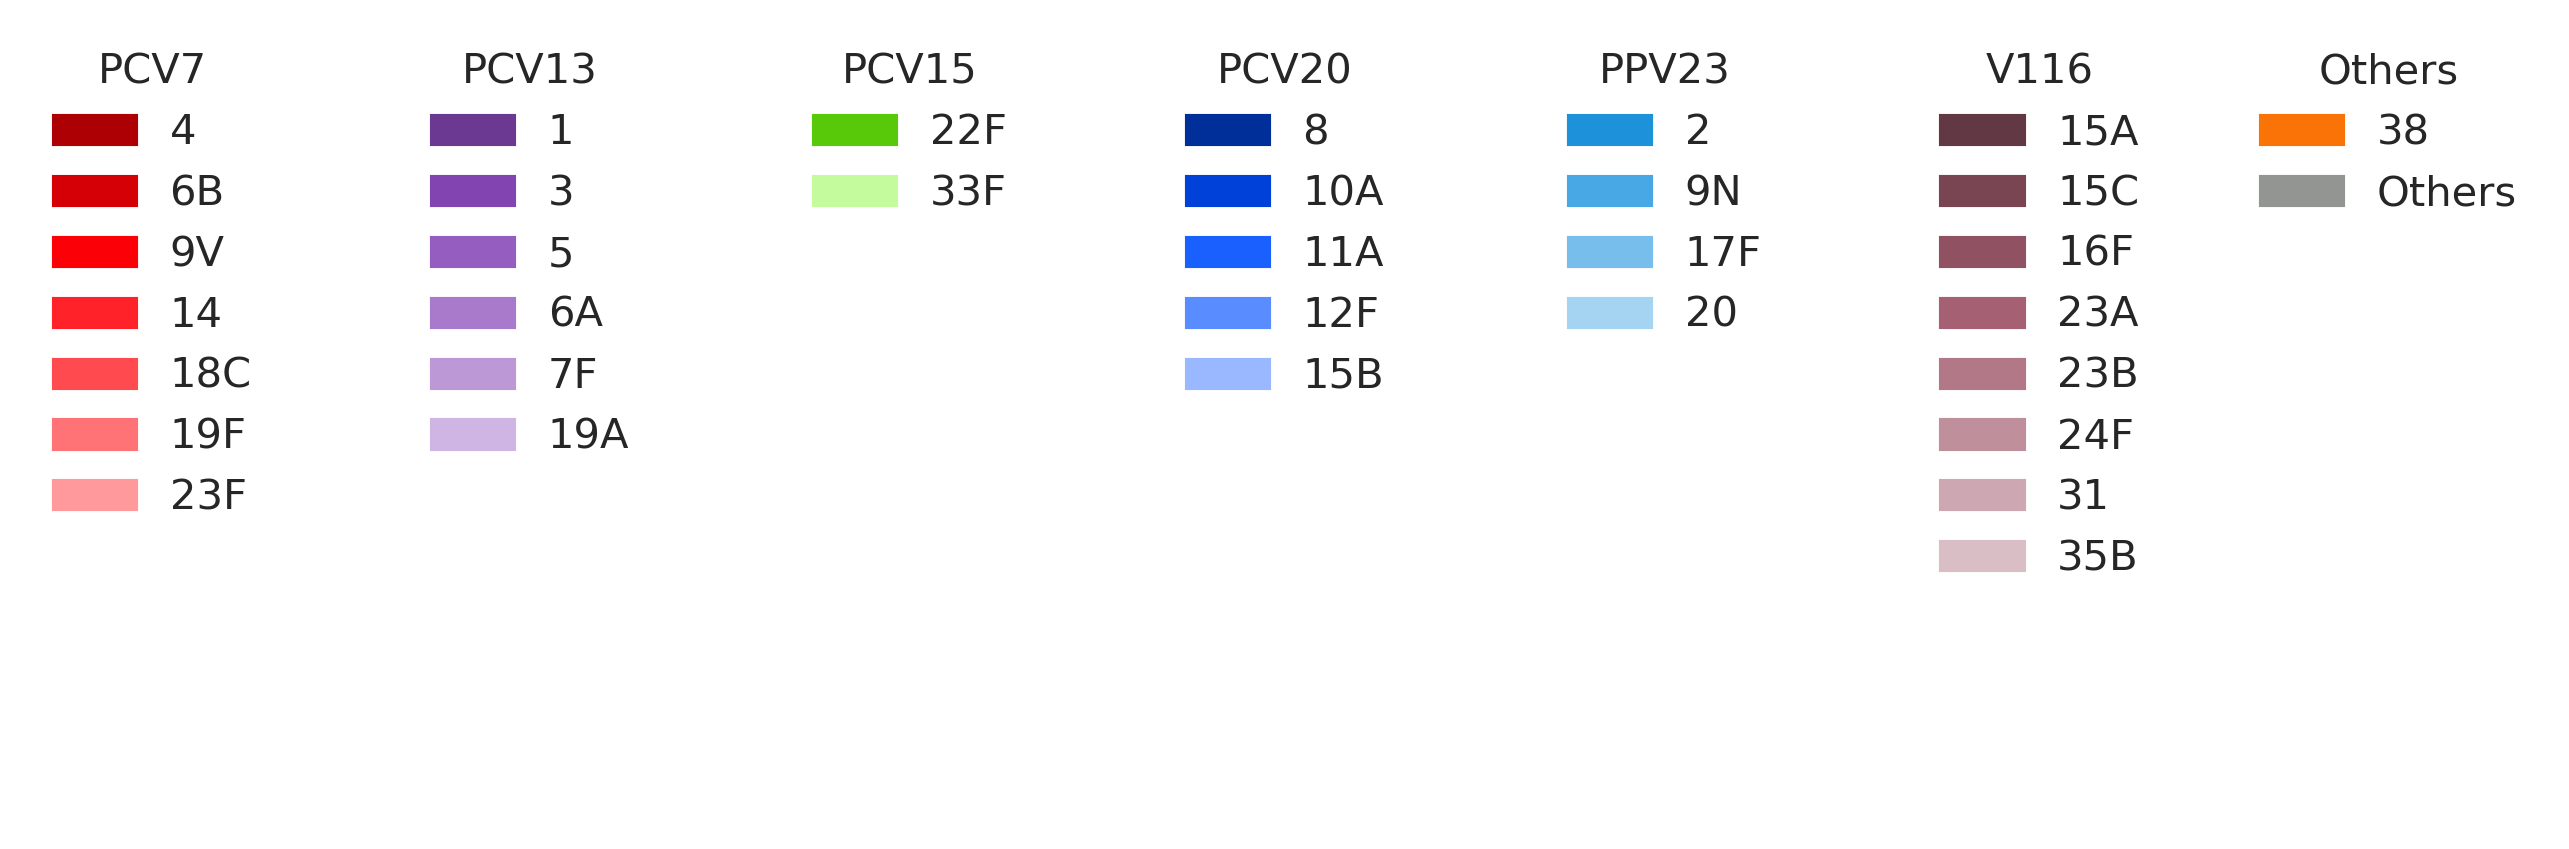

In [84]:
# Vaccine groups in order
vaccine_groups = {
    'PCV7': pcv7,
    'PCV13': pcv13,
    'PCV15': pcv15,
    'PCV20': pcv20,
    'PPV23': ppv23,
    'V116': v116,
    'Others': [st for st in color_dict if st not in set(sum([pcv7, pcv13, pcv15, pcv20, ppv23, v116], [])) and st != 'Others'] + ['Others']
}

n_cols = len(vaccine_groups)

fig, axes = plt.subplots(1, n_cols, figsize=(2.5 * n_cols, 6))

# If only one column, wrap axes into list for uniformity
if n_cols == 1:
    axes = [axes]

for ax, (group_name, serotypes) in zip(axes, vaccine_groups.items()):
    patches = [mpatches.Patch(color=color_dict[st], label=st) for st in serotypes if st in color_dict]
    ax.legend(handles=patches, title=group_name, fontsize=20, title_fontsize=20, frameon=False)
    ax.axis('off')

plt.tight_layout()

plt.savefig('../../out/figures/serotypes_distribution_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('../../out/figures/serotypes_distribution_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

plt.show()

In [85]:
df

,lab-nr,working-nr,sample-nr,patient-nr,material,others,sepsis,HIV+,meningitis,covid,date,age,sex,serotype_pheno,serotype_geno,serogroup_match,serotype_match,serotype_cons,serotype_cons_reason,ST,GPSC,bad_quality,penicillin_men_geno,penicillin_nonmen_geno,penicillin_MIC_geno,pbp1a,pbp2b,pbp2x,ceftriaxone_men_geno,ceftriaxone_nonmen_geno,ceftriaxone_MIC_geno,amoxicillin_geno,amoxicillin_MIC_geno,year,vaccine_period,isVT,isPCV7,isPCV13,isPCV15,age_group,isNVT,pre-PCV7,PCV7,early-PCV13,late-PCV13,PCV15,COVID19,dominant_serotype,dominant_GPSC,serotype_filtered_plot
0,3727299,1,1212.09,1387686.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-30,88,M,17F,17F,Match,Match,17F,NaN,1924,49,NaN,S,S,0.03,11,0,172,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,0,0.0,17F
1,3727298,2,1212.08,991560.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-29,71,M,3,3,Match,Match,3,NaN,1377,83,NaN,S,S,0.03,62,0,2,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,>=65 years,0,0,0,0,0,0,1,1,1.0,3
2,3726089,3,1211.77,500374.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-28,66,F,8,8,Match,Match,8,NaN,53,3,NaN,S,S,0.03,3,6,5,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0,8
3,3725476,4,1211.70,1652756.0,material_blood,1.0,0.0,0.0,1.0,1.0,2022-03-26,55,F,19A,19A,Match,Match,19A,NaN,199,4,NaN,S,S,0.03,1,0,187,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,45-64 years,0,0,0,0,0,0,1,1,1.0,19A
4,3718136,5,1211.49,555401.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-20,65,M,12F,12F,Match,Match,12F,NaN,218,32,NaN,S,S,0.03,0,0,0,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0,12F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,24K-351B0173,1342,1248.14,NaN,material_other,NaN,NaN,NaN,NaN,NaN,2024-12-14,63,M,22F,22F,Match,Match,22F,NaN,433,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,45-64 years,0,0,0,0,0,1,0,1,1.0,22F
1308,24K-351B0174,1343,1248.15,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,78,M,19F,19F,Match,Match,19F,NaN,179,44,> 150 contigs,S,S,0.03,23,0,139,S,S,0.5,S,0.03,2024,PCV15,1,1,0,0,>=65 years,0,0,0,0,0,1,0,1,0.0,19F
1309,24K-351B0255,1344,1248.17,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,58,M,35B,35B,Match,Match,35B,NaN,3003,72,NaN,S,S,0.03,0,0,2,S,S,0.5,S,0.03,2024,PCV15,0,0,0,0,45-64 years,1,0,0,0,0,1,0,0,0.0,35B
1310,24K-360B0073,1345,1248.63,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-24,84,F,22F,22F,Match,Match,22F,NaN,10220,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,>=65 years,0,0,0,0,0,1,0,1,1.0,22F


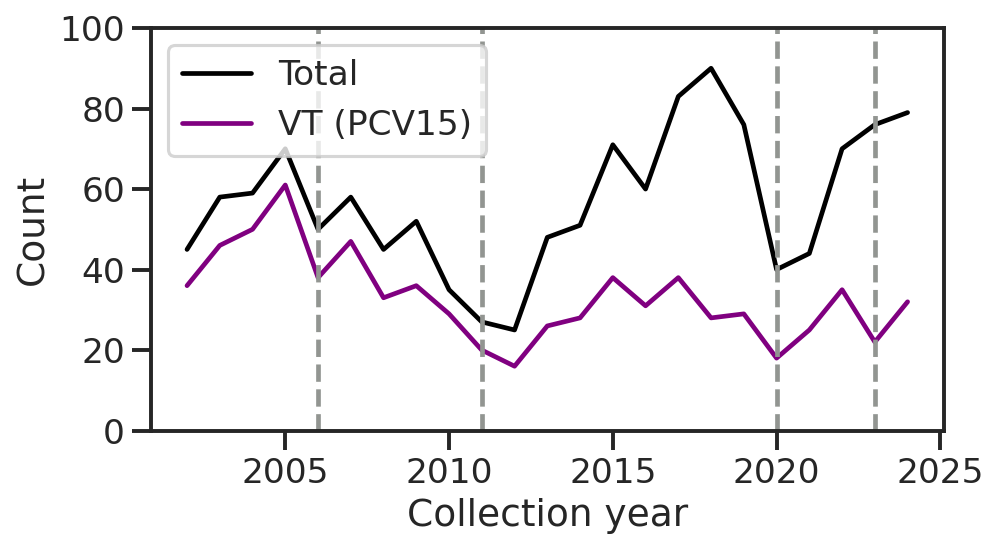

In [86]:
# Group by year and count total isolates
total_counts = df.groupby('year').size()

# Count VT isolates
vt_counts = df.loc[df["isVT"] == 1].groupby("year").size()

# Align indices (fill missing years with 0)
all_years = sorted(df['year'].unique())
total_counts = total_counts.reindex(all_years, fill_value=0)
vt_counts = vt_counts.reindex(all_years, fill_value=0)

# Plot
plt.figure(figsize=(7,4))
plt.plot(all_years, total_counts, color='black', label='Total')
plt.plot(all_years, vt_counts, color='purple', label='VT (PCV15)')

plt.axvline(x=2011, color='xkcd:grey', linestyle='--')
plt.axvline(x=2006, color='xkcd:grey', linestyle='--')
plt.axvline(x=2020, color='xkcd:grey', linestyle='--')
plt.axvline(x=2023, color='xkcd:grey', linestyle='--')

plt.xlabel('Collection year')
plt.ylabel('Count')

plt.ylim(0,100)

plt.legend(facecolor='white')
plt.tight_layout()
plt.savefig('../../out/figures/total_count.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/total_count.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


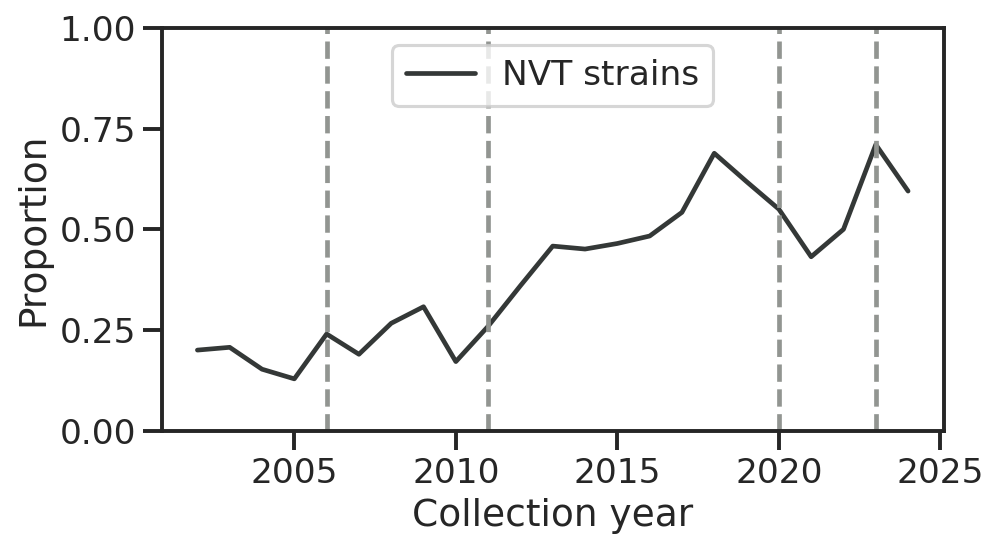

In [87]:
# Calculate NVT proportion
nvt_prop = 1 - (vt_counts / total_counts)

# Plot
plt.figure(figsize=(7,4))
sns.lineplot(x=all_years, y=nvt_prop, color="xkcd:charcoal", label='NVT strains')

# Vertical line at 2011
plt.axvline(x=2011, color='xkcd:grey', linestyle='--')
plt.axvline(x=2006, color='xkcd:grey', linestyle='--')
plt.axvline(x=2020, color='xkcd:grey', linestyle='--')
plt.axvline(x=2023, color='xkcd:grey', linestyle='--')

plt.xlabel('Collection year')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.yticks([0, 0.25, 0.50, 0.75, 1])
plt.legend(facecolor='white')
plt.tight_layout()
plt.savefig('../../out/figures/NVT_prevalence.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/NVT_prevalence.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

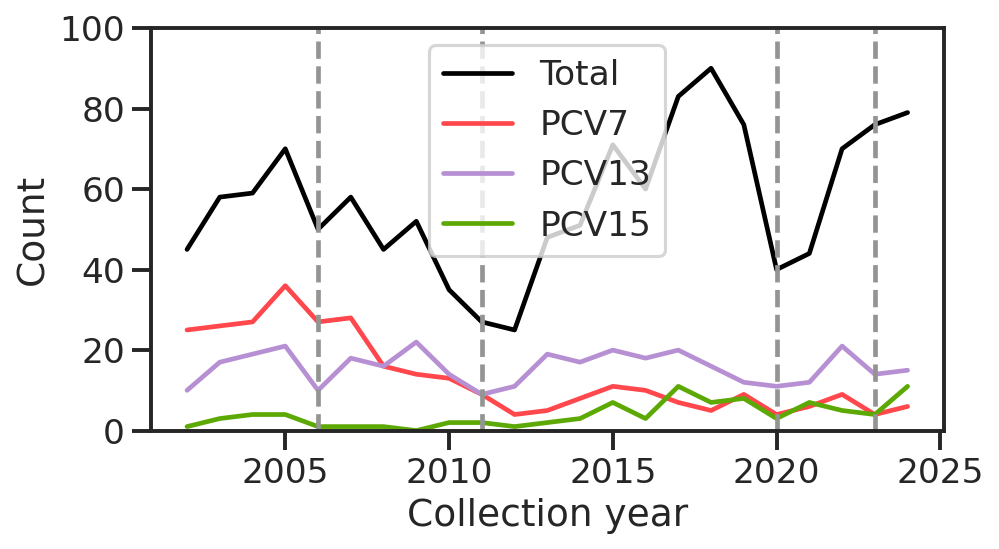

In [88]:
# Group by year and count total isolates
total_counts = df.groupby('year').size()

# Count VT isolates
pcv7_counts = df.loc[df["isPCV7"] == 1].groupby("year").size()
pcv13_counts = df.loc[df["isPCV13"] == 1].groupby("year").size()
pcv15_counts = df.loc[df["isPCV15"] == 1].groupby("year").size()

# Align indices (fill missing years with 0)
all_years = sorted(df['year'].unique())
total_counts = total_counts.reindex(all_years, fill_value=0)
pcv7_counts = pcv7_counts.reindex(all_years, fill_value=0)
pcv13_counts = pcv13_counts.reindex(all_years, fill_value=0)
pcv15_counts = pcv15_counts.reindex(all_years, fill_value=0)

# Plot
plt.figure(figsize=(7,4))
plt.plot(all_years, total_counts, color='black', label='Total')
plt.plot(all_years, pcv7_counts, color='#ff474c', label='PCV7')
plt.plot(all_years, pcv13_counts, color='#b790d4', label='PCV13')
plt.plot(all_years, pcv15_counts, color='#5ca904', label='PCV15')

plt.axvline(x=2011, color='xkcd:grey', linestyle='--')
plt.axvline(x=2006, color='xkcd:grey', linestyle='--')
plt.axvline(x=2020, color='xkcd:grey', linestyle='--')
plt.axvline(x=2023, color='xkcd:grey', linestyle='--')

plt.xlabel('Collection year')
plt.ylabel('Count')

plt.ylim(0,100)

plt.legend(facecolor='white')
plt.tight_layout()
plt.savefig('../../out/figures/total_count_PCVs.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/total_count_PCVs.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/software.9/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as

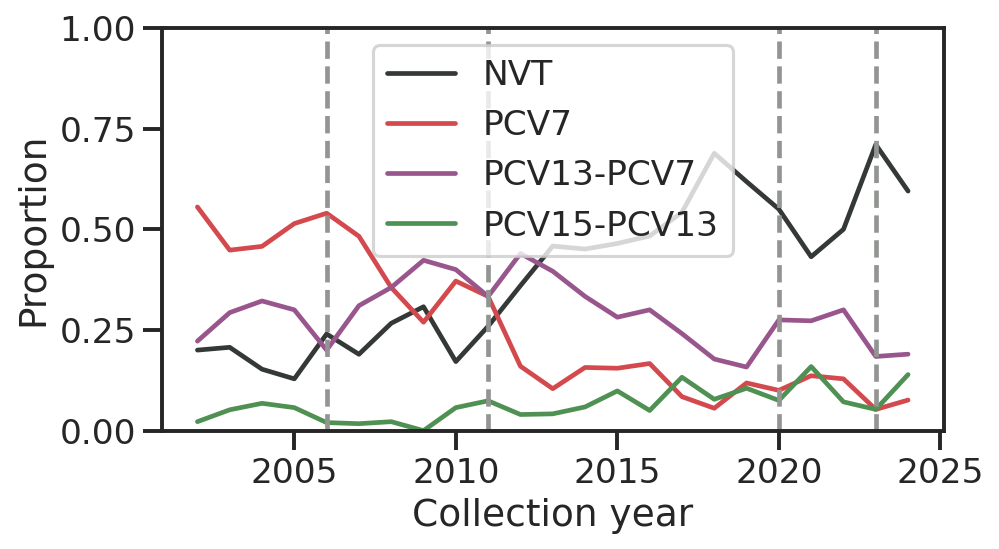

In [89]:
# Calculate NVT proportion
nvt_prop = 1 - (vt_counts / total_counts)
pcv7_prop = (pcv7_counts / total_counts)
pcv13_prop = (pcv13_counts / total_counts)
pcv15_prop = (pcv15_counts / total_counts)

# Plot
plt.figure(figsize=(7,4))
sns.lineplot(x=all_years, y=nvt_prop, color="xkcd:charcoal", label='NVT')
sns.lineplot(x=all_years, y=pcv7_prop, color="#d3494e", label='PCV7')
sns.lineplot(x=all_years, y=pcv13_prop, color="#98568d", label='PCV13-PCV7')
sns.lineplot(x=all_years, y=pcv15_prop, color="#4f9153", label='PCV15-PCV13')

# Vertical line at 2011
plt.axvline(x=2011, color='xkcd:grey', linestyle='--')
plt.axvline(x=2006, color='xkcd:grey', linestyle='--')
plt.axvline(x=2020, color='xkcd:grey', linestyle='--')
plt.axvline(x=2023, color='xkcd:grey', linestyle='--')

plt.xlabel('Collection year')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.yticks([0, 0.25, 0.50, 0.75, 1])
plt.legend(facecolor='white')
plt.tight_layout()
plt.savefig('../../out/figures/NVT_PCV_prevalence.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/NVT_PCV_prevalence.svg',
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

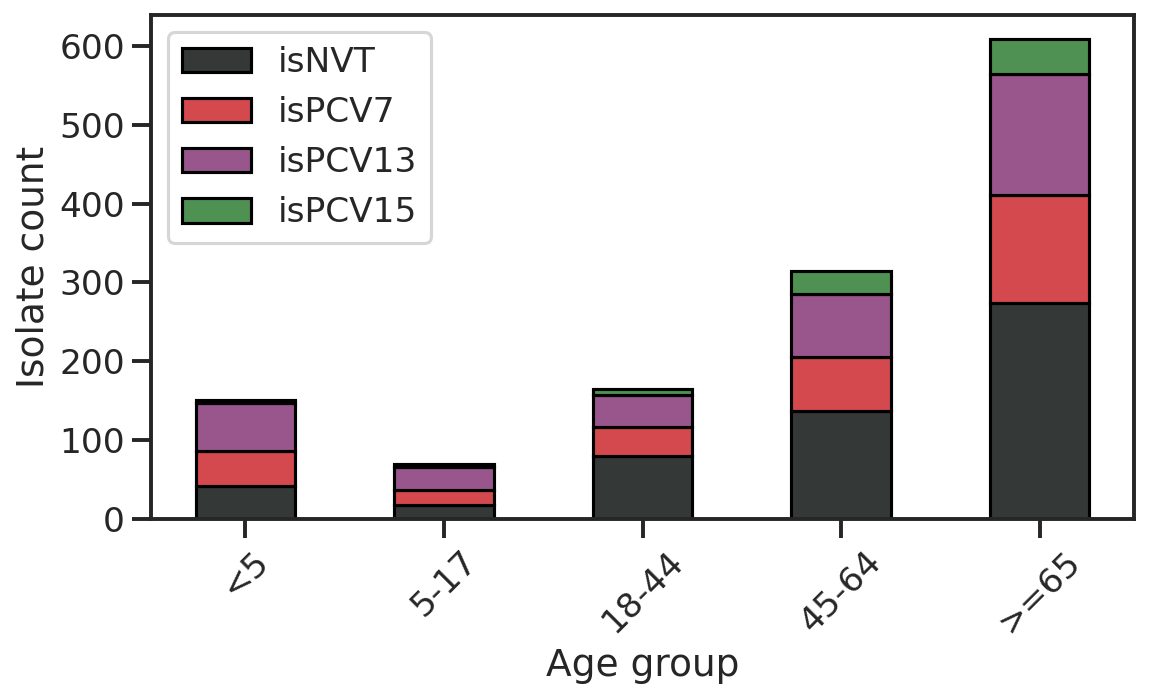

In [90]:
# Colors for strains
strain_colors = {
    "isNVT": "xkcd:charcoal",
    "isPCV7": "#d3494e",
    "isPCV13": "#98568d",
    "isPCV15": "#4f9153"
}

cols = ["isNVT", "isPCV7", "isPCV13", "isPCV15"]

# Original and shortened age groups
age_order_old = ["<5 years", "5-17 years", "18-44 years", "45-64 years", ">=65 years"]
age_order_new = ["<5", "5-17", "18-44", "45-64", ">=65"]

# Drop rows with NaNs
df_clean = df.dropna(subset=cols + ['age_group'])

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(age_order_old))
bar_width = 0.5  # single bar per age group

# Keep track of bottom for stacking
bottom = pd.Series([0]*len(age_order_old), index=age_order_old)

for col in cols:
    counts = df_clean.groupby('age_group')[col].sum().reindex(age_order_old, fill_value=0)
    ax.bar(x, counts, width=bar_width, bottom=bottom, color=strain_colors[col], edgecolor='black', label=col)
    bottom += counts  # update bottom for next strain

# X-axis labels: use shortened labels
ax.set_xticks(x)
ax.set_xticklabels(age_order_new, rotation=45)
ax.set_ylabel("Isolate count")
ax.set_xlabel("Age group")
ax.legend(facecolor="white")
plt.tight_layout()
plt.savefig('../../out/figures/agegroup_PCV.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/agegroup_PCV.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [91]:
df

,lab-nr,working-nr,sample-nr,patient-nr,material,others,sepsis,HIV+,meningitis,covid,date,age,sex,serotype_pheno,serotype_geno,serogroup_match,serotype_match,serotype_cons,serotype_cons_reason,ST,GPSC,bad_quality,penicillin_men_geno,penicillin_nonmen_geno,penicillin_MIC_geno,pbp1a,pbp2b,pbp2x,ceftriaxone_men_geno,ceftriaxone_nonmen_geno,ceftriaxone_MIC_geno,amoxicillin_geno,amoxicillin_MIC_geno,year,vaccine_period,isVT,isPCV7,isPCV13,isPCV15,age_group,isNVT,pre-PCV7,PCV7,early-PCV13,late-PCV13,PCV15,COVID19,dominant_serotype,dominant_GPSC,serotype_filtered_plot
0,3727299,1,1212.09,1387686.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-30,88,M,17F,17F,Match,Match,17F,NaN,1924,49,NaN,S,S,0.03,11,0,172,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,0,0.0,17F
1,3727298,2,1212.08,991560.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-29,71,M,3,3,Match,Match,3,NaN,1377,83,NaN,S,S,0.03,62,0,2,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,>=65 years,0,0,0,0,0,0,1,1,1.0,3
2,3726089,3,1211.77,500374.0,material_blood,1.0,0.0,0.0,0.0,0.0,2022-03-28,66,F,8,8,Match,Match,8,NaN,53,3,NaN,S,S,0.03,3,6,5,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0,8
3,3725476,4,1211.70,1652756.0,material_blood,1.0,0.0,0.0,1.0,1.0,2022-03-26,55,F,19A,19A,Match,Match,19A,NaN,199,4,NaN,S,S,0.03,1,0,187,S,S,<= 0.5,S,<= 0.03,2022,COVID19,1,0,1,0,45-64 years,0,0,0,0,0,0,1,1,1.0,19A
4,3718136,5,1211.49,555401.0,material_blood,1.0,1.0,0.0,0.0,0.0,2022-03-20,65,M,12F,12F,Match,Match,12F,NaN,218,32,NaN,S,S,0.03,0,0,0,S,S,<= 0.5,S,<= 0.03,2022,COVID19,0,0,0,0,>=65 years,1,0,0,0,0,0,1,1,1.0,12F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,24K-351B0173,1342,1248.14,NaN,material_other,NaN,NaN,NaN,NaN,NaN,2024-12-14,63,M,22F,22F,Match,Match,22F,NaN,433,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,45-64 years,0,0,0,0,0,1,0,1,1.0,22F
1308,24K-351B0174,1343,1248.15,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,78,M,19F,19F,Match,Match,19F,NaN,179,44,> 150 contigs,S,S,0.03,23,0,139,S,S,0.5,S,0.03,2024,PCV15,1,1,0,0,>=65 years,0,0,0,0,0,1,0,1,0.0,19F
1309,24K-351B0255,1344,1248.17,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-15,58,M,35B,35B,Match,Match,35B,NaN,3003,72,NaN,S,S,0.03,0,0,2,S,S,0.5,S,0.03,2024,PCV15,0,0,0,0,45-64 years,1,0,0,0,0,1,0,0,0.0,35B
1310,24K-360B0073,1345,1248.63,NaN,material_blood,NaN,NaN,NaN,NaN,NaN,2024-12-24,84,F,22F,22F,Match,Match,22F,NaN,10220,19,NaN,S,S,0.03,1,2,2,S,S,0.5,S,0.03,2024,PCV15,1,0,0,1,>=65 years,0,0,0,0,0,1,0,1,1.0,22F


In [92]:
print(df.columns.tolist())

['lab-nr', 'working-nr', 'sample-nr', 'patient-nr', 'material', 'others', 'sepsis', 'HIV+', 'meningitis', 'covid', 'date', 'age', 'sex', 'serotype_pheno', 'serotype_geno', 'serogroup_match', 'serotype_match', 'serotype_cons', 'serotype_cons_reason', 'ST', 'GPSC', 'bad_quality', 'penicillin_men_geno', 'penicillin_nonmen_geno', 'penicillin_MIC_geno', 'pbp1a', 'pbp2b', 'pbp2x', 'ceftriaxone_men_geno', 'ceftriaxone_nonmen_geno', 'ceftriaxone_MIC_geno', 'amoxicillin_geno', 'amoxicillin_MIC_geno', 'year', 'vaccine_period', 'isVT', 'isPCV7', 'isPCV13', 'isPCV15', 'age_group', 'isNVT', 'pre-PCV7', 'PCV7', 'early-PCV13', 'late-PCV13', 'PCV15', 'COVID19', 'dominant_serotype', 'dominant_GPSC', 'serotype_filtered_plot']


/scratch/local/332170/ipykernel_3861165/1355460345.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['vaccine_period_renamed'] = df_top['vaccine_period'].map(vaccine_rename)


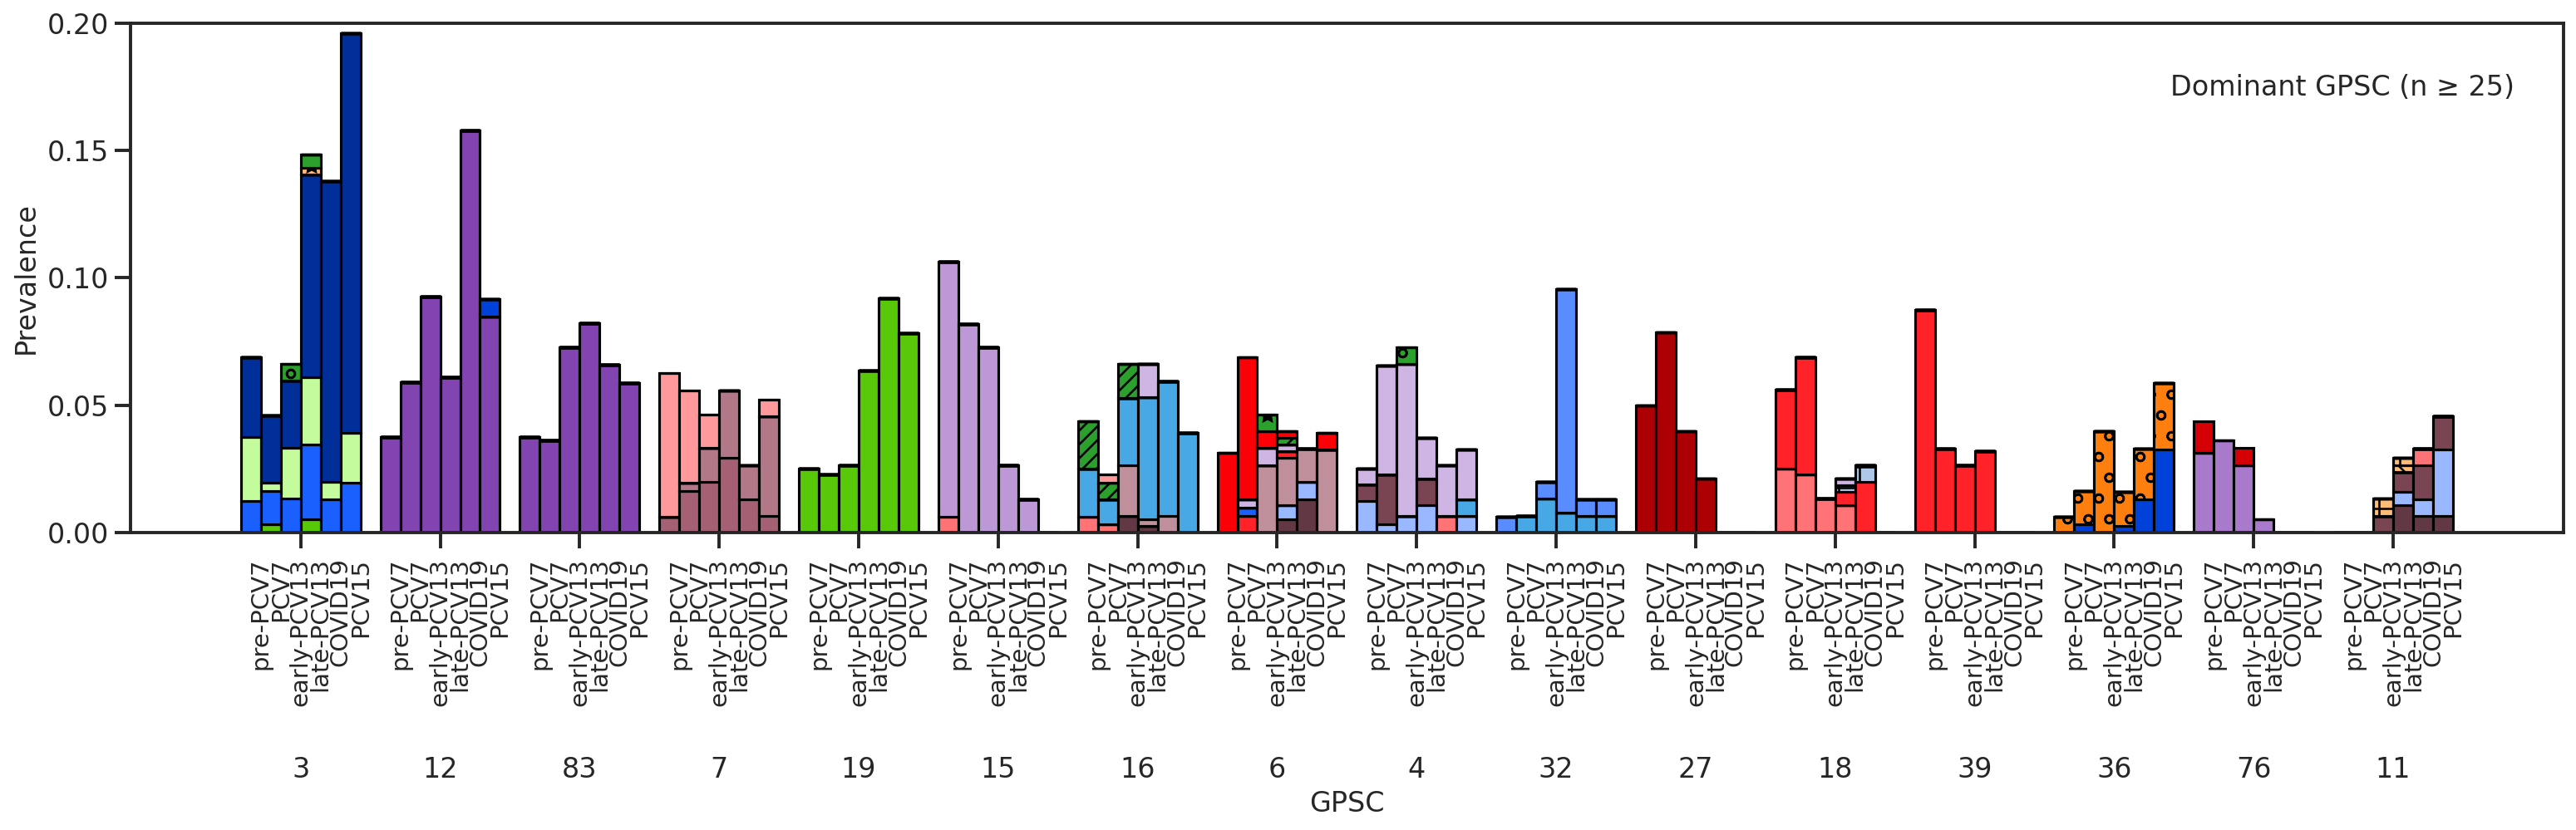

In [100]:
vaccine_cols = df["vaccine_period"].unique().tolist()

# --- Step 0: Prep ---
df['GPSC'] = df['GPSC'].astype(str)
df['ST'] = df['ST'].astype(str)
dfs = df[~df['GPSC'].isna() & (df['GPSC'] != "nan") & (df['GPSC'] != "Not_assigned")]

# --- Step 1: Calculate proportions per vaccine period ---
vaccine_cols = df["vaccine_period"].unique().tolist()
dfs_proportions = {}
for period in vaccine_cols:
    temp = dfs[dfs[period] == 1]
    counts = temp.groupby(['GPSC', 'serotype_cons']).size().reset_index(name='count')
    total = counts['count'].sum()
    counts['proportion'] = counts['count'] / total
    dfs_proportions[period] = counts

combined_df = pd.concat(
    [dfs.assign(vaccine_period=period) for period, dfs in dfs_proportions.items()],
    ignore_index=True
)

# --- Step 2: Select dominant GPSCs (from full dataset) ---
counts = df['GPSC'].value_counts()
GPSC_dominant = counts[counts > 24].index.astype(str).tolist()
df_top = combined_df[combined_df['GPSC'].isin(GPSC_dominant)]

# --- Step 3: Rename vaccine periods ---
vaccine_rename = {
    'pre-PCV7': "pre-PCV7",
    'PCV7': 'PCV7',
    'early-PCV13': "early-PCV13",
    "late-PCV13": "late-PCV13",
    'COVID19': "COVID19",
    'PCV15': "PCV15"
}
df_top['vaccine_period_renamed'] = df_top['vaccine_period'].map(vaccine_rename)
vaccine_order = list(vaccine_rename.keys())

# --- Step 4: Colors and hatches ---
color_maps = [plt.cm.tab20.colors, plt.cm.tab20b.colors, plt.cm.tab20c.colors,
              plt.cm.Set3.colors, plt.cm.Paired.colors, plt.cm.Dark2.colors,
              plt.cm.Accent.colors, plt.cm.Pastel1.colors]
base_colors = [c for cmap in color_maps for c in cmap]
hatches = ['', '///', '\\\\', '+', 'o', '*']
style_combos = [(c, h) for c in base_colors for h in hatches]

unique_sts = df_top['serotype_cons'].unique()
color_map, hatch_map = {}, {}
for i, st in enumerate(unique_sts):
    if st in soi:  # predefined serotypes of interest
        color_map[st] = soi[st]
        hatch_map[st] = ''
    else:
        color_map[st], hatch_map[st] = style_combos[i % len(style_combos)]

plt.rcParams['hatch.linewidth'] = 1.25
plt.rcParams['hatch.color'] = 'black'

# --- Step 5: Ensure all combinations exist ---
df_top_complete = (
    df_top.set_index(['GPSC', 'vaccine_period', 'serotype_cons'])
    .reindex(pd.MultiIndex.from_product(
        [GPSC_dominant, vaccine_order, unique_sts],
        names=['GPSC', 'vaccine_period', 'serotype_cons']
    ), fill_value=0)
    .reset_index()
)
df_top_complete['vaccine_period_renamed'] = df_top_complete['vaccine_period'].map(vaccine_rename)

# --- Step 6: Plotting ---
fig, ax = plt.subplots(figsize=(21, 7))

bar_width = 0.15
gap = 0.05
n_periods = len(vaccine_order)
x = np.arange(len(GPSC_dominant)) * (n_periods * bar_width + gap + 0.1)

# Plot stacked bars
for j, period in enumerate(vaccine_order):
    for i, gpsc in enumerate(GPSC_dominant):
        temp = df_top_complete[
            (df_top_complete['GPSC'] == gpsc) &
            (df_top_complete['vaccine_period'] == period)
        ]
        bottom = 0
        for _, row in temp.iterrows():
            st = row['serotype_cons']
            ax.bar(
                x[i] + j * bar_width, row['proportion'], bottom=bottom,
                width=bar_width, color=color_map[st], hatch=hatch_map[st],
                edgecolor='black'
            )
            bottom += row['proportion']

# X-ticks and labels
ax.set_xticks(x + (n_periods - 1) * bar_width / 2)
ax.set_xticklabels(GPSC_dominant, fontsize=16, rotation=0)
ax.tick_params(axis='x', which='major', pad=120)

# Y-axis
ax.set_ylim(0, 0.2)
ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20])
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel('GPSC', fontsize=16)
ax.set_ylabel('Prevalence', fontsize=16)

# Vaccine period labels under each bar
for j, period in enumerate(vaccine_order):
    period_label = vaccine_rename[period]
    positions = x + j * bar_width + bar_width / 2
    for pos in positions:
        ax.text(pos, -0.01, period_label, ha='center', va='top', rotation=90, fontsize=14)

ax.text(
    0.98, 0.9, f"Dominant GPSC (n ≥ 25)",
    ha='right', va='top', fontsize=16,
    transform=ax.transAxes
)

plt.tight_layout()

plt.savefig('../../out/figures/dominant_GPSC_Serotype_distribution.png',
            dpi=300, bbox_inches='tight', transparent=True)
plt.savefig('../../out/figures/dominant_GPSC_Serotype_distribution.svg',
            dpi=300, bbox_inches='tight', transparent=True)

plt.show()

/scratch/local/332170/ipykernel_3861165/1897791716.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


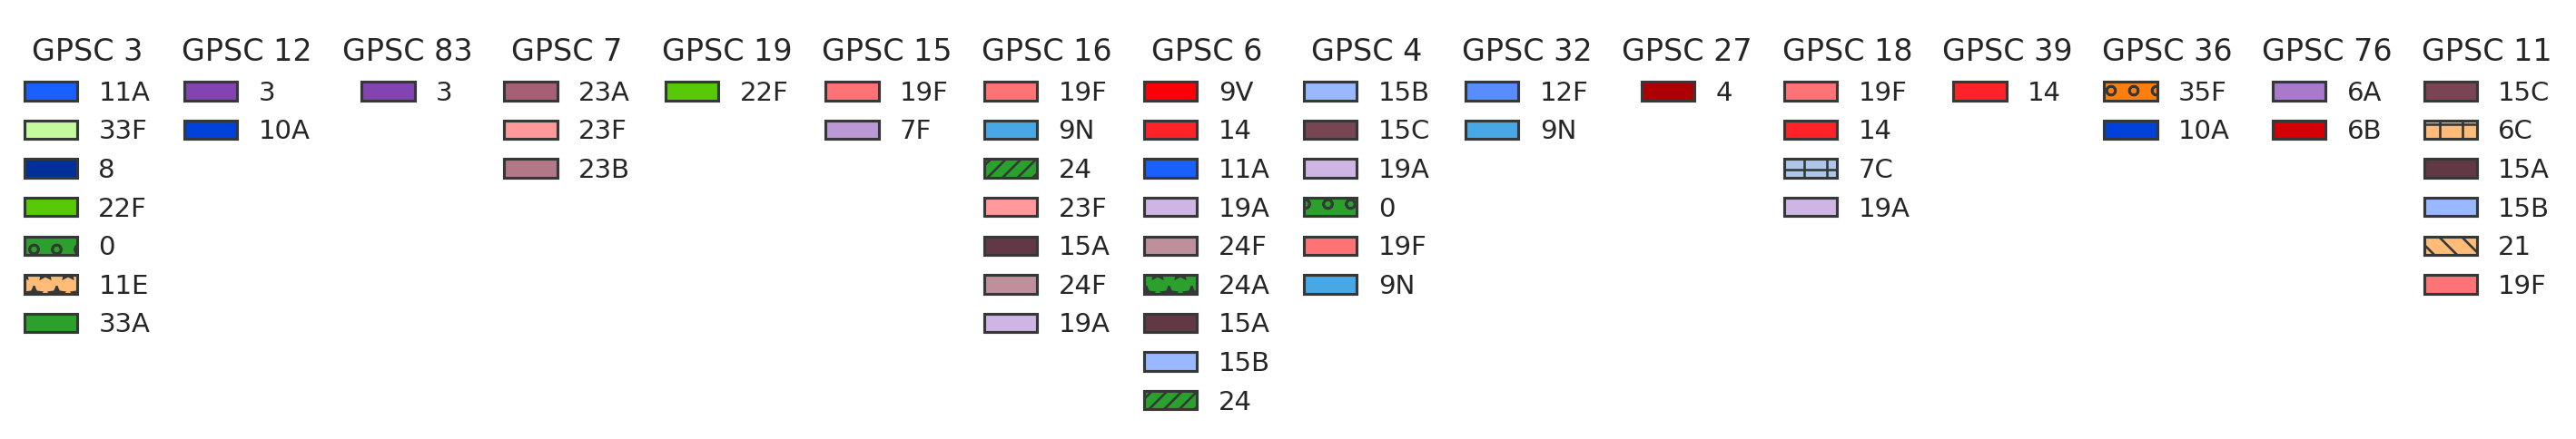

In [122]:
# --- Single figure with top-aligned GPSC legends ---
n_gpsc = len(GPSC_dominant)
fig_legend, axes = plt.subplots(1, n_gpsc, figsize=(1.5*n_gpsc, 4), squeeze=False, 
                                gridspec_kw={'top': 0.85})  # leave space at top

for j, gpsc in enumerate(GPSC_dominant):
    ax_leg = axes[0, j]
    ax_leg.axis('off')  # hide axes

    # Serotypes present for this GPSC
    sts_present = df_top_complete[df_top_complete['GPSC'] == gpsc]
    sts_present = sts_present[sts_present['proportion'] > 0]['serotype_cons'].unique()
    
    # Handles and labels
    handles = [
        plt.Rectangle((0, 0), 1, 1,
                      facecolor=color_map[st],
                      hatch=hatch_map[st],
                      edgecolor='xkcd:charcoal')
        for st in sts_present
    ]
    labels = list(sts_present)
    
    # Legend with 1 column, larger fonts
    legend = ax_leg.legend(handles, labels, title=f"GPSC {gpsc}", loc='upper center',
                           frameon=False, ncol=1, fontsize=14, title_fontsize=16)

plt.tight_layout()

plt.savefig('../../out/figures/dominant_GPSC_Serotype_distribution_legend.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True)

plt.show()